In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import CenteredNorm

En parkeringsplads på $20 \text{m} \times 30 \text{m}$ bliver oplyst via lamper placeret forskellige steder og i forskellige højde, som angivet i figur 1.

![fig1](C:/Users/henri/OneDrive%20-%20Aarhus%20universitet/2.%20Semester/Numerisk%20Lineær%20Algebra/TØ/Opgavesæt%2010/Billeder/Figur1.png)

Parkeringspladsen inddeles i en rektangulær gitter af 600 kvadrater hver af størrelse $1 \text{m} \times 1 \text{m}$. Tallet $y_{j}$ angiver belysningsniveauet i kvadrat $j$, for
$j = 0,\dots,599$. Lad $x_{i}$ angiver styrken af lampe $i$. Vi vælger enheder så at bidraget til belysningen i kvadrat $j$ fra lampe $i$ er $\frac{x_{i}}{d_{ij}^{2}}$, hvor $d_{ij}$ er afstanden i $\mathbb{R}^{3}$ fra lampen til centrum af kvadrat $j$.

$\pagebreak$

## (a) {-}

Angiv hvordan belysningsniveauet $y = (y_{0}, \dots, y_{599})$ og styrkerne $x = (x_{0}, \dots, x_{11})$ er relateret via et lineært ligningssystem. Opstil koefficientmatricen for systemet i python. (I må estimere koordinaterne for placeringen af hver lampe ud fra diagrammet.)

Det vides fra den givne formel, hvordan belysningsniveauet og styrkerne er relateret til hinanden gennem afstanden. Da afstanden kan beregnes uafhængigt af styrkerne, vil dette blive koefficientmatricen for systemet. Ligningssystemet kommer da til at se ud som således, hvor den første $\mathbb{R}^{600 \times 12}$ matrix er koefficientmatricen:

$$
\begin{bmatrix}
\frac{1}{d_{0,0}^{2}} & \frac{1}{d_{1,0}^{2}} & \dots & \frac{1}{d_{11,0}^{2}} \\
\frac{1}{d_{0,1}^{2}} & \frac{1}{d_{1,1}^{2}} & \dots & \frac{1}{d_{11,1}^{2}} \\
\vdots & \vdots & \vdots & \vdots \\
\frac{1}{d_{0,599}^{2}} & \frac{1}{d_{1,599}^{2}} & \dots & \cdot \frac{1}{d_{11,599}^{2}}
\end{bmatrix}
\begin{bmatrix}
x_{0} \\
x_{1} \\
\vdots \\
x_{11}
\end{bmatrix}
=
\begin{bmatrix}
y_{0} \\
y_{1} \\
\vdots \\
y_{599}
\end{bmatrix}
$$

In [2]:
# Definerer lampe positioner
lamper = np.array([ [2.0, 4.0,  4.0,  11.0, 12.0, 13.0, 15.0, 16.0, 20.0, 23.0, 25.0, 28.0], 
                    [3.0, 13.0, 19.0, 5.0,  12.0, 18.0, 2.0,  16.0, 4.0,  12.0, 16.0, 9.0],
                    [3.0, 3.6,  3.0,  3.5,  4.0,  3.6,  4.5,  3.0,  2.8,  4.0,  3.8,  3.4]])

A = np.ones((600, 12), dtype=float) # Skabelon for koefficientmatricen

for i in range(12):
    for j in range(600):
        kvadrat_x = j%30 + 0.5  # Angiver kvadraternes x-koordinat
        kvadrat_y = j//30 + 0.5 # Angiver kvadraternes y-koordinat

        # Beregner afstand
        d = np.sqrt((lamper[0][i] - kvadrat_x)**2 + \
                    (lamper[1][i] - kvadrat_y)**2 + (lamper[2][i])**2)
        # Indsætter afstand i koefficientmatricen
        A[j][i] = 1 / d**2

print("Koefficientmatricen bliver da:\n", A)

Koefficientmatricen bliver da:
 [[0.05714286 0.00551086 0.00275103 ... 0.00152788 0.00116967 0.00119039]
 [0.06451613 0.0056993  0.0027972  ... 0.001638   0.00123925 0.00127217]
 [0.06451613 0.00583226 0.00282885 ... 0.00175901 0.00131416 0.00136229]
 ...
 [0.00107354 0.0016462  0.00178094 ... 0.01081081 0.03035823 0.00819269]
 [0.00101678 0.00152565 0.00164069 ... 0.0097561  0.02568053 0.00819269]
 [0.00096386 0.00141751 0.0015163  ... 0.00873362 0.02130379 0.00806062]]


## (b) {-}

Lav en heatplot der viser belysningsniveauet i hver kvadrat når alle lampe er tændt med styrke $x_{i} = 20.0$.

Da koefficientmatricen allerede er opstillet i forrige opgave, skal dataene for styrkerne blot opsættes og ganges på for at få belysningsniveauet.

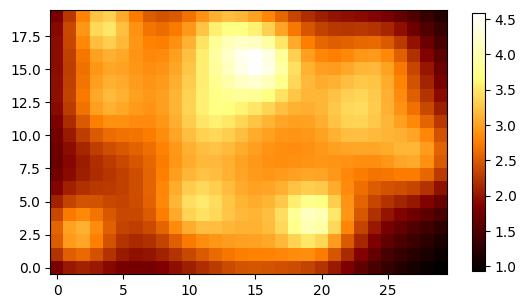

In [3]:
X = np.ones((12, 1)) * 20.0 # Opsætter alle styrker som 20
Y = A @ X                   # Finder belysningsniveau

plt.imshow(Y.reshape(20, 30), cmap='afmhot') # Opstiller heatmap
plt.gca().invert_yaxis() # Inverterer y-aksen da python vender den på hovedet
plt.colorbar(shrink=0.7) # Laver referencesøjle til belysningsniveau

$\pagebreak$

## (c) {-}

Der ønskes at belysningsniveauet bliver så tæt så muligt på 1,0 i alle kvadrater. Brug den mindste kvadraters metode til at bestemme i python lysstyrken i hver lampe ved brug af (i) QR-dekomponering via forbedret Gram-Schmidt, hhv. (ii) SVD-dekomponering. Bekræft at løsningen er fysisk relevant, ved at tjekke om alle styrker er positive

### (i) {-}

In [4]:
# Funktion fået fra notesættet afsnit 15.3
def forbedret_gram_schmidt(a):
    _, k = a.shape
    q = np.copy(a)
    r = np.zeros((k, k))
    for i in range(k):
        r[i, i] = np.linalg.norm(q[:, i])
        q[:, i] /= r[i, i]
        r[[i], i+1:] = q[:, [i]].T @ q[:, i+1:]
        q[:, i+1:] -= q[:, [i]] @ r[[i], i+1:]
    return q, r

# Funktion fået fra notesættet afsnit 16.4
def back_subs(r, c):
    _, n = r.shape
    x = np.empty((n, 1))
    for i in reversed(range(n)):
        x[i] = (c[i] - r[[i], i+1:] @ x[i+1:]) / r[i, i]
    return x

In [5]:
q, r = forbedret_gram_schmidt(A) # Laver QR-dekomponering med gram-schmidt
b = np.ones_like(Y)              # Opstiller de ønskede belysningsværdier

X_QR = back_subs(r, q.T @ b) # Løser som i ligning 16.4 fra notesættet

np.all(X_QR >= 0) # Tjekker om alle styrker er positive

True

### (ii) {-}

In [6]:
u, s, vt = np.linalg.svd(A, full_matrices=False) # Laver en tynd SVD

X_SVD = vt.T @ np.linalg.inv(np.diag(s)) @ u.T @ b # Indsætter i ligning 16.5

np.all(X_SVD >= 0)

True

$\pagebreak$

## (d) {-}

Lav en heatplot af resultaterne fra del (c) på en måde, som bedst illustrerer hvor tæt værdierne er på den ønskede. Hvad er den maksimale afvigelse fra den ønskede værdi 1.0? Er der stor forskel mellem resultaterne fra de to metoder?

Først findes belysningsniveauerne ud fra de beregnede styrker på samme vis som i opgave b. For at vise hvor tæt værdierne ligger på målet, plottes den relative afvigelse, som kan findes ved:
$$
\text{relativ afvigelse } = \frac{\text{estimeret værdi } - \text{ mål}}{\text{mål}}
$$
Da alle de ønskede belysningsniveauer dog er på 1, er der ingen grund til at dele med målet.

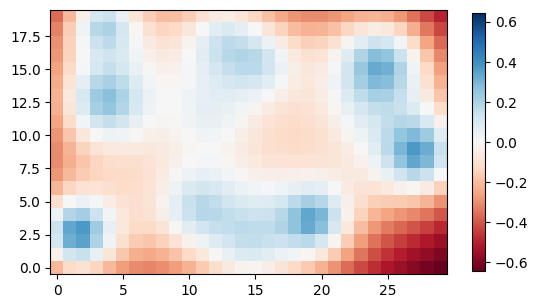

In [28]:
Y_QR = (A @ X_QR).reshape(20, 30)   # Beregner belysningsniveau ud fra QR
Y_GOAL = b.reshape(20, 30)          # Opstiller de ønskede belysningsværdier
diff_QR = Y_QR - Y_GOAL             # Beregner afvigelse

# For at giv bedre overblik centreres der, 
# så de tætteste værdier (afvigelse = 0) er hvid
plt.imshow(diff_QR, norm=CenteredNorm(), cmap='RdBu')
plt.gca().invert_yaxis()
plt.colorbar(shrink=0.7)

$\pagebreak$

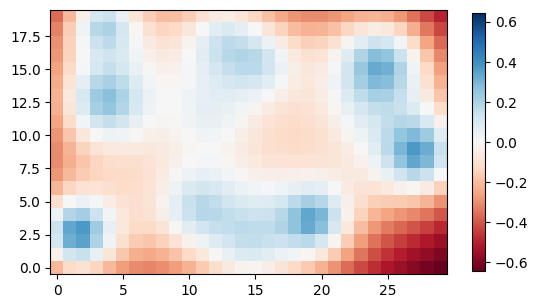

In [29]:
Y_SVD = (A @ X_SVD).reshape(20, 30) # Beregner belysningsniveau ud fra SVD
diff_SVD = Y_SVD - Y_GOAL

plt.imshow(diff_SVD, norm=CenteredNorm(), cmap='RdBu')
plt.gca().invert_yaxis()
plt.colorbar(shrink=0.7)

Det kan ses at områderne omkring lamperne praktisk talt er belysningsniveauet de skal være. Hjørnerne som ligger langt fra lamperne har mest afvigelse, hvilket præciseres forneden.

In [32]:
print(f"Den største positive afvigelse fra 1 for QR løsningen er på {np.max(diff_QR)}, mens den største negative afvigelse er {np.min(diff_QR)}\n")
print(f"Den største positive afvigelse fra 1 for SVD løsningen er på {np.max(diff_SVD)}, mens den største negative afvigelse er {np.min(diff_SVD)}")

Den største positive afvigelse fra 1 for QR løsningen er på 0.37006690497837114, mens den største negative afvigelse er -0.6446631480975298

Den største positive afvigelse fra 1 for SVD løsningen er på 0.37006690497837047, mens den største negative afvigelse er -0.6446631480975296


Både heatmaps og afvigelser mellem de to løsningsmetoder har næsten ingen forskel. Dette kan understreges ved at finde forskellen mellem deres størrelser.

In [31]:
np.linalg.norm(Y_QR - Y_GOAL) - np.linalg.norm(Y_SVD - Y_GOAL)

0.0

## (e) {-}

Beregn tallene $\kappa(A)$, $\cos(\theta)$ og $\eta$, som styrer konditionstallene for problemet (sml. notesæt 17). Angiv den tilsvarende øvre grænse for konditionstallet for hvordan ændring i $A$ påvirker ændring i den beregnede $x$ i del (c). Brug dette til at forklare hvor nøjagtig I kan forvente beregning af $x$ til at være.

Da begge løsninger ca. er det samme nøjes der med SVD løsningen her. Derudover bruges formlerne fra det angivede notesæt.

In [10]:
# Med brug af singulærværdierne fundet fra SVD på koefficientmatricen tidligere
kA = s[0] / s[-1]

# Her bruges b fra opgave C, samt x-værdierne fra SVD mindste kvadraters metode
cos_theta = np.linalg.norm(A @ X_SVD) / np.linalg.norm(b)

eta = s[0] * (np.linalg.norm(X_SVD) / np.linalg.norm(A @ X_SVD))

print(f"κ(A) = kA \ncos(θ) = {cos_theta} \nη = {eta}")

κ(A) = kA 
cos(θ) = 0.9839509931803877 
η = 1.1810148986167568


In [11]:
theta = np.arccos(cos_theta)
limit = kA + (kA**2 * np.abs(np.tan(theta))) / eta
print("Den øvre grænse for konditionstallet vil være:", limit)

Den øvre grænse for konditionstallet vil være: 18.638807553737074


Da den øvre grænse for konditionstallet ved ændring af koefficientmatricen, $A$, er 18.6 vil det betyde, at fejlen ligger på en størrelsesorden 10, hvilket er acceptabelt jvf. notesæt 11.